# Modelisation simple

Utilisons:
- $ I = 1 $
- $ f_c (Q, i) = l_i $ , avec $ l_{-1}, l_{+1} $ constantes
- $ \lambda_i^+(Q) = \alpha_i$
- $ \lambda_i^-(Q) = \beta_i  1_{Q_i > 0}$
- $ \lambda_i^T(Q) = \gamma_i  1_{Q_i > 0}$

Ce modèle n'utilisera pas les fonctions $ \lambda^A, \lambda^B$.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass

In [3]:
# Initialisation des paramètres

# Convention d'indices :
# i = -1 -> première limite acheteuse
# i = +1 -> première limite vendeuse

alphas = {-1: 5.0, 1: 5.0}   # intensités d'ajout
betas  = {-1: 0.3, 1: 0.3}   # intensités d'annulation
gammas = {-1: 2.0, 1: 2.0}   # intensités de transaction

# f_c(Q, i) = l_i, avec l_i constant
l = {-1: "bid", 1: "ask"}

# Tables d'intensité par label
lambda_add_by_label    = {"bid": alphas[-1], "ask": alphas[1]}
lambda_cancel_by_label = {"bid": betas[-1],  "ask": betas[1]}
lambda_trade_by_label  = {"bid": gammas[-1], "ask": gammas[1]}

# Quantités initiales
Q0 = {-1: 10, 1: 10}

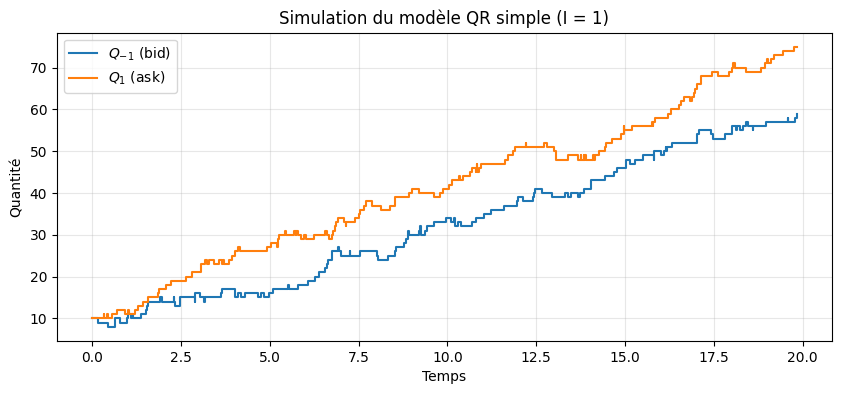

Nombre d'événements simulés : 292
Dernier état : {-1: 59, 1: 75}
5 premiers événements :
(0.16467182218945167, 'trade', -1, 2.0, 9, 10)
(0.3280116167013869, 'add', 1, 5.0, 9, 11)
(0.3339319865437415, 'trade', 1, 2.0, 9, 10)
(0.4305046368353561, 'add', 1, 5.0, 9, 11)
(0.4359357462314869, 'trade', -1, 2.0, 8, 11)


In [4]:
def f(Q, i):
    """Fonction de réduction d'état : ici constante en Q."""
    return l[i]

def lambda_add(Q, i):
    """Intensité d'ajout sur la file i."""
    state = f(Q, i)
    return lambda_add_by_label[state]

def lambda_cancel(Q, i):
    """Intensité d'annulation sur la file i.
    Elle est nulle si la file est vide.
    """
    state = f(Q, i)
    return lambda_cancel_by_label[state] if Q[i] > 0 else 0.0

def lambda_trade(Q, i):
    """Intensité de transaction sur la file i.
    Elle est nulle si la file est vide.
    """
    state = f(Q, i)
    return lambda_trade_by_label[state] if Q[i] > 0 else 0.0

def event_list(Q):
    """Liste des événements possibles et de leurs intensités."""
    events = [
        ("add", -1, lambda_add(Q, -1)),
        ("cancel", -1, lambda_cancel(Q, -1)),
        ("trade", -1, lambda_trade(Q, -1)),
        ("add",  1, lambda_add(Q,  1)),
        ("cancel", 1, lambda_cancel(Q, 1)),
        ("trade",  1, lambda_trade(Q, 1)),
    ]
    return [(typ, i, rate) for typ, i, rate in events if rate > 0]

def total_intensity(Q):
    """Intensité totale du prochain saut."""
    return sum(rate for _, _, rate in event_list(Q))

def sample_next_event(Q, rng):
    """Tire le prochain temps d'événement et le type d'événement.

    Retourne
    --------
    dt : float
        Temps jusqu'au prochain événement.
    event : tuple
        (type_evenement, file_i, intensité)
    """
    events = event_list(Q)
    Lambda = sum(rate for _, _, rate in events)
    if Lambda <= 0:
        raise ValueError("Aucun événement possible depuis cet état.")

    dt = rng.exponential(1.0 / Lambda)
    probs = np.array([rate for _, _, rate in events], dtype=float) / Lambda
    idx = rng.choice(len(events), p=probs)
    return dt, events[idx]

def apply_event(Q, event):
    """Applique un événement à l'état Q."""
    event_type, i, _ = event
    new_Q = Q.copy()

    if event_type == "add":
        new_Q[i] += 1
    elif event_type in ("cancel", "trade"):
        if new_Q[i] > 0:
            new_Q[i] -= 1
    else:
        raise ValueError(f"Type d'événement inconnu : {event_type}")

    return new_Q

def simulate_qr(T=10.0, Q_init=None, seed=None, max_events=100_000):
    """Simule le modèle QR simple jusqu'au temps T.

    Paramètres
    ----------
    T : float
        Horizon de simulation.
    Q_init : dict
        Etat initial {-1: q_bid, 1: q_ask}.
    seed : int ou None
        Graine aléatoire.
    max_events : int
        Sécurité pour éviter une boucle trop longue.

    Retourne
    --------
    times : np.ndarray
    q_bid : np.ndarray
    q_ask : np.ndarray
    event_history : list
        Liste de tuples (t, event_type, i, rate, q_bid_after, q_ask_after).
    """
    rng = np.random.default_rng(seed)
    Q = Q0.copy() if Q_init is None else Q_init.copy()

    t = 0.0
    times = [t]
    q_bid = [Q[-1]]
    q_ask = [Q[1]]
    event_history = []

    n_events = 0
    while t < T and n_events < max_events:
        dt, event = sample_next_event(Q, rng)

        if t + dt > T:
            break

        t += dt
        Q = apply_event(Q, event)

        times.append(t)
        q_bid.append(Q[-1])
        q_ask.append(Q[1])

        event_type, i, rate = event
        event_history.append((t, event_type, i, rate, Q[-1], Q[1]))
        n_events += 1

    return np.array(times), np.array(q_bid), np.array(q_ask), event_history

def plot_simulation(times, q_bid, q_ask):
    """Affiche l'évolution des deux files."""
    plt.figure(figsize=(10, 4))
    plt.step(times, q_bid, where="post", label=r"$Q_{-1}$ (bid)")
    plt.step(times, q_ask, where="post", label=r"$Q_{1}$ (ask)")
    plt.xlabel("Temps")
    plt.ylabel("Quantité")
    plt.title("Simulation du modèle QR simple (I = 1)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Exemple de simulation
times, q_bid, q_ask, event_history = simulate_qr(T=20.0, Q_init=Q0, seed=42)
plot_simulation(times, q_bid, q_ask)

print(f"Nombre d'événements simulés : {len(event_history)}")
print("Dernier état :", {-1: int(q_bid[-1]), 1: int(q_ask[-1])})
print("5 premiers événements :")
for x in event_history[:5]:
    print(x)

## Vérification rapide des probabilités du prochain événement

À un état donné $ Q $, la probabilité que le prochain événement soit $ e $ vaut
$$
\mathbb P(e \mid Q)=
{\lambda_e(Q)} / {\Lambda(Q)},
\qquad
\Lambda(Q)=\sum_{e'} \lambda_{e'}(Q).
$$

On peut calculer ces probabilités explicitement.

In [5]:
def next_event_probabilities(Q):
    events = event_list(Q)
    Lambda = sum(rate for _, _, rate in events)
    return {(typ, i): rate / Lambda for typ, i, rate in events}

Q_test = {-1: 10, 1: 10}
probs = next_event_probabilities(Q_test)

print("Probabilités du prochain événement à l'état Q =", Q_test)
for key, value in probs.items():
    print(f"{key}: {value:.4f}")

Probabilités du prochain événement à l'état Q = {-1: 10, 1: 10}
('add', -1): 0.3425
('cancel', -1): 0.0205
('trade', -1): 0.1370
('add', 1): 0.3425
('cancel', 1): 0.0205
('trade', 1): 0.1370
